#  014c · AR-MA · Laboratorio · La Ventosa por **regímenes**

**Estadística, Detección de Anomalías e Imputación de Series Temporales**  
Posgrado en Ingeniería · Área Energía · IER-UNAM

Variante de [014b](./014b_LaVentosa.ipynb) que aplica **la misma libreta** a dos
sub-periodos del verano 2023, escogidos por inspección de la serie completa que
muestra **dos regímenes muy distintos**:

- **Régimen A — débil / térmico local** (1 jun – 15 jul): viento típico 0–4 m/s.
  Predomina la variabilidad térmica diurna sobre flujo sinóptico débil.
- **Régimen B — activo / canalización Tehuantepecana** (20 jul – 20 ago): viento
  típico 5–9 m/s. Forzamiento sinóptico fuerte que activa el canal del Istmo.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.random.seed(42)

## Helpers — los dos pasos del ciclo, codificados

- `mirar()`: identificación (ADF + ACF + PACF).
- `diagnostico()`: validación (residuales + ACF residual + Ljung-Box).

In [17]:
def mirar(serie, nombre, lags=30):
    """Identificación: serie temporal + ADF + ACF + PACF."""
    serie = pd.Series(serie).dropna()

    stat, p, *_ = adfuller(serie, autolag="AIC")
    veredicto = "estacionaria" if p < 0.05 else "NO estacionaria"
    print(f"ADF · {nombre}:  estadístico = {stat:.3f},  p = {p:.4f}  →  {veredicto}")

    fig, axes = plt.subplot_mosaic(
        [["serie", "serie"],
         ["acf",   "pacf"]],
        figsize=(12, 6),
    )
    serie.plot(ax=axes["serie"], lw=0.5, color="C0")
    axes["serie"].axhline(serie.mean(), color="k", lw=0.5, alpha=0.5)
    axes["serie"].set_title(f"Serie — {nombre}")
    plot_acf(serie,  lags=lags, ax=axes["acf"]);  axes["acf"].set_title(f"ACF — {nombre}")
    plot_pacf(serie, lags=lags, ax=axes["pacf"], method="ywm")
    axes["pacf"].set_title(f"PACF — {nombre}")
    plt.tight_layout(); plt.show()


def diagnostico(modelo, nombre, lags=20):
    """Validación: residuales + ACF residual + PACF residual + Ljung-Box."""
    p, d, q = modelo.model.order
    resid = modelo.resid.iloc[max(p, q):]

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
    axes[0].plot(resid.values, lw=0.6); axes[0].axhline(0, color="k", lw=0.5)
    axes[0].set_title(f"Residuales — {nombre}")
    plot_acf(resid,  lags=lags, ax=axes[1]); axes[1].set_title("ACF de residuales")
    plot_pacf(resid, lags=lags, ax=axes[2], method="ywm")
    axes[2].set_title("PACF de residuales")
    plt.tight_layout(); plt.show()

    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    print(f"Ljung-Box · {nombre}")
    print(lb.round(4))
    return lb

## P1 · Los datos · La Ventosa, Oaxaca · 5 min

- **Sitio:** 16.55°N, 94.78°W. Corredor eólico del Istmo de Tehuantepec, uno de los
  mayores recursos eólicos del continente. Vientos térmicos por contraste de presión
  entre el Golfo de México y el Pacífico, canalizados por el istmo.
- **Periodo:** jun–ago 2023, resolución horaria — partido en dos regímenes (ver más abajo).
- **Variable:** velocidad del viento a 10 m.
- **Fuente:** ERA5 (reanálisis ECMWF) vía Open-Meteo.

**Por qué este dataset para enseñar ARMA:**
- ~2200 obs → potencia estadística suficiente.
- Ciclo diario explícito → enseña por qué hay que desestacionalizar antes.
- Persistencia no trivial → forzará iterar Box-Jenkins (no se cierra al primer intento).
- Relevante para el alumno (energía eólica).


2208 obs horarias · 2023-06-01 00:00:00 a 2023-08-31 23:00:00
media = 4.14 m/s,  desv = 2.37 m/s,  máx = 9.36 m/s


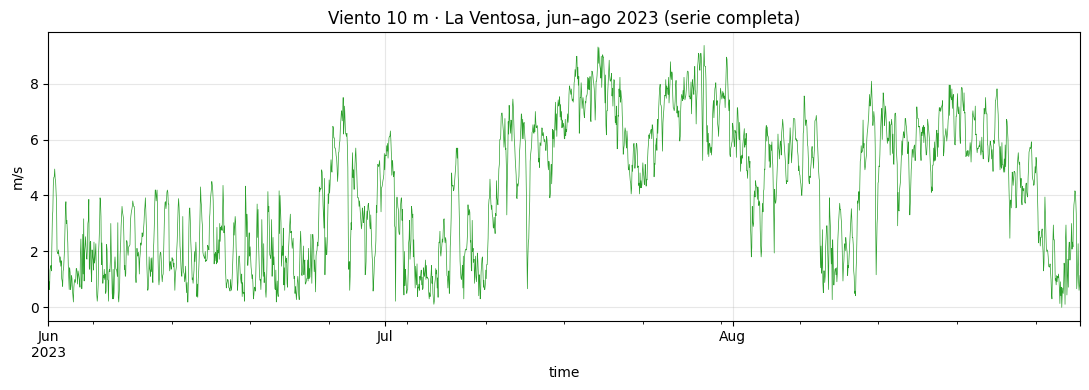

In [19]:
viento = pd.read_csv("../data/viento_la_ventosa_2023.csv",
                     skiprows=3, parse_dates=["time"],
                     index_col="time")
viento.columns = ["ws_kmh"]
viento["ws"] = viento["ws_kmh"] / 3.6  # km/h → m/s
viento = viento["ws"]

print(f"{len(viento)} obs horarias · {viento.index.min()} a {viento.index.max()}")
print(f"media = {viento.mean():.2f} m/s,  desv = {viento.std():.2f} m/s,  máx = {viento.max():.2f} m/s")

viento.plot(lw=0.5, color="C2",
            title="Viento 10 m · La Ventosa, jun–ago 2023 (serie completa)")
plt.ylabel("m/s"); plt.tight_layout(); plt.show()


### Cambio de régimen visible — partimos la serie

A simple vista la serie tiene **dos regímenes muy distintos** separados por una
transición a mediados de julio:

- **Régimen A · débil / térmico local** (1 jun – 15 jul): viento típico
  0–4 m/s. Predomina la variabilidad térmica diurna sobre flujo sinóptico débil.
- **Régimen B · activo / canalización Tehuantepecana** (20 jul – 20 ago): viento
  típico 5–9 m/s. Forzamiento sinóptico fuerte que activa el canal del Istmo.

Se omiten a propósito la transición (15–20 jul) y el colapso terminal de fin de
agosto — los regímenes son **no complementarios**.

Aplicamos la libreta **a uno de los dos**. Cambiando `regimen` abajo y corriendo
**Run All**, todo el laboratorio (climatología, ADF, ACF/PACF, iteración
Box-Jenkins, backtest) se recalcula sobre el subconjunto sin tocar nada más.
Para discutir en clase: comparar entre A y B los $\phi_i$, la amplitud del ciclo
climatológico, el orden ARMA ganador y el MAE en backtest.


768 obs · 2023-07-20 00:00:00 a 2023-08-20 23:00:00
media = 5.72 m/s,  desv = 1.86 m/s


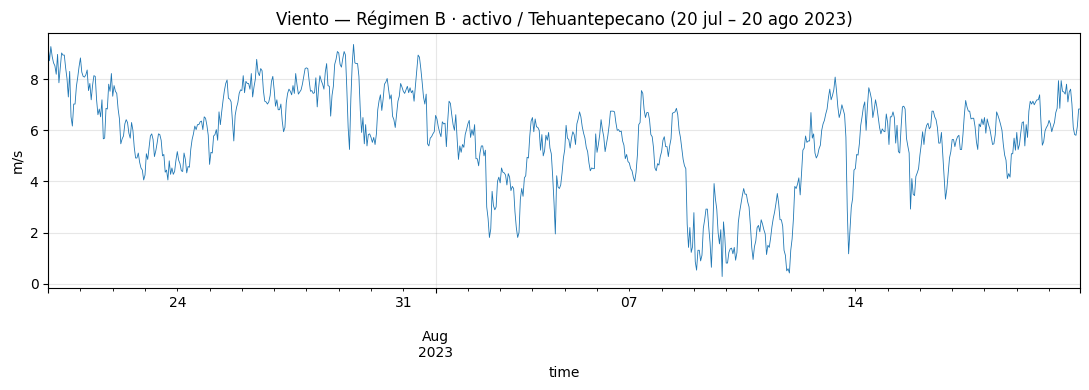

In [20]:
# ─────────────────────── selección de régimen ───────────────────────
regimen = "B"   # "A" = débil / térmico  ·  "B" = activo / Tehuantepecano

if   regimen == "A":
    viento = viento.loc["2023-06-01":"2023-07-15"]
    etiqueta = "Régimen A · débil / térmico (1 jun – 15 jul 2023)"
elif regimen == "B":
    viento = viento.loc["2023-07-20":"2023-08-20"]
    etiqueta = "Régimen B · activo / Tehuantepecano (20 jul – 20 ago 2023)"
# ────────────────────────────────────────────────────────────────────

print(f"{len(viento)} obs · {viento.index.min()} a {viento.index.max()}")
print(f"media = {viento.mean():.2f} m/s,  desv = {viento.std():.2f} m/s")

viento.plot(lw=0.6, color="C0", title=f"Viento — {etiqueta}")
plt.ylabel("m/s"); plt.tight_layout(); plt.show()


## P2 · ¿Podemos usar AR-MA aquí? · 10 min

In [5]:
stat, p, *_ = adfuller(viento, autolag="AIC")
print(f"ADF sobre serie cruda:  p = {p:.4f}  →  "
      f"{'estacionaria' if p < 0.05 else 'NO estacionaria'}")

ADF sobre serie cruda:  p = 0.0146  →  estacionaria


### Confirmación visual — ACF y PACF de la serie cruda

ACF/PACF son la **otra ruta** (además de la climatología) para detectar estacionalidad:
si hay un ciclo de período $s$, aparecen picos en lags $s, 2s, 3s, \dots$

ADF · viento crudo:  estadístico = -3.307,  p = 0.0146  →  estacionaria


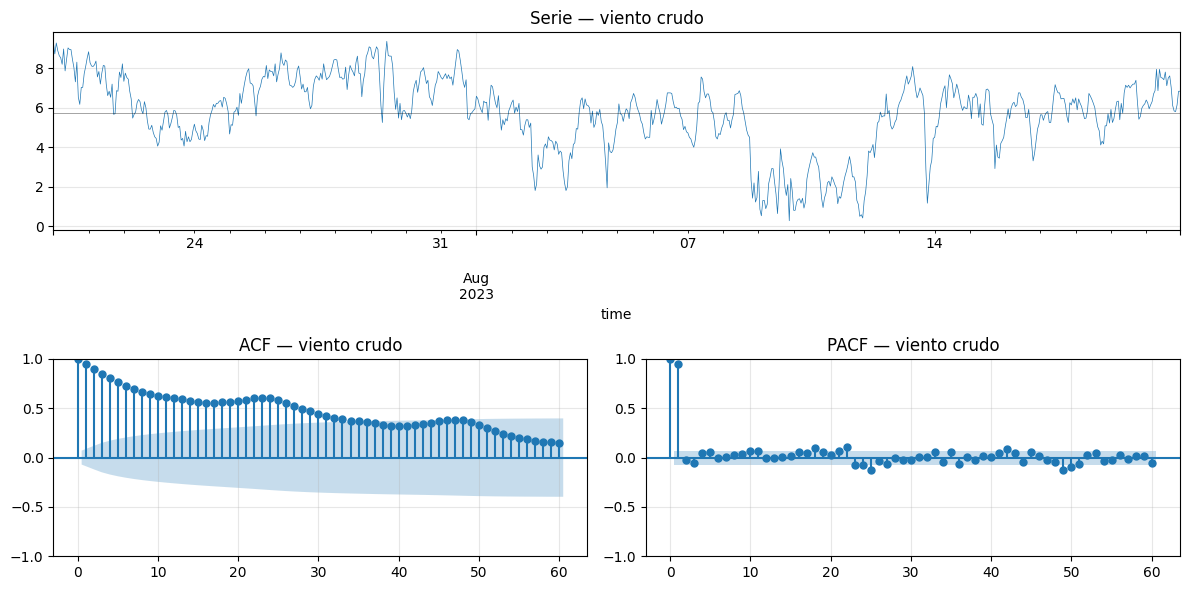

In [21]:
mirar(viento, "viento crudo", lags=60)

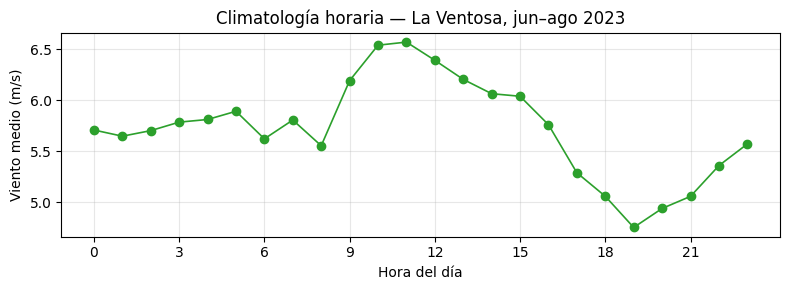

Rango climatológico: 4.75 a 6.57 m/s
Amplitud diaria:     1.82 m/s


In [22]:
clima_h = viento.groupby(viento.index.hour).mean()

fig, ax = plt.subplots(figsize=(8, 3))
clima_h.plot(ax=ax, marker="o", lw=1.2, color="C2")
ax.set_xlabel("Hora del día"); ax.set_ylabel("Viento medio (m/s)")
ax.set_title("Climatología horaria — La Ventosa, jun–ago 2023")
ax.set_xticks(range(0, 24, 3))
plt.tight_layout(); plt.show()

print(f"Rango climatológico: {clima_h.min():.2f} a {clima_h.max():.2f} m/s")
print(f"Amplitud diaria:     {clima_h.max() - clima_h.min():.2f} m/s")

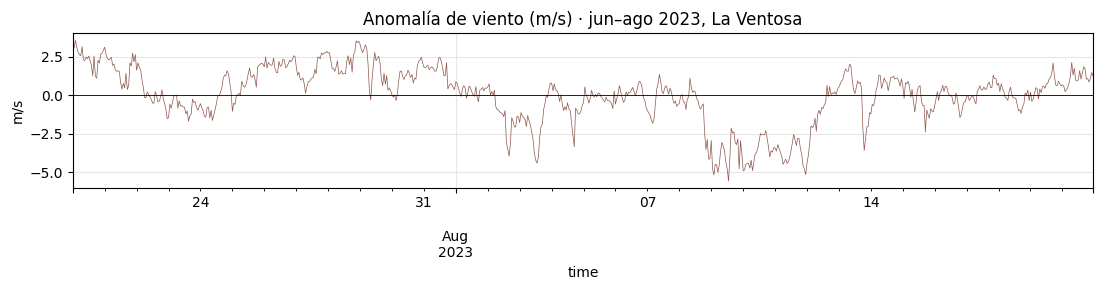

In [23]:
ws_anom = viento - viento.index.hour.map(clima_h)

fig, ax = plt.subplots(figsize=(11, 3))
ws_anom.plot(ax=ax, lw=0.5, color="C5")
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Anomalía de viento (m/s) · jun–ago 2023, La Ventosa")
ax.set_ylabel("m/s")
plt.tight_layout(); plt.show()

## P3 · Identificación · 5 min

ADF · anomalía viento:  estadístico = -4.260,  p = 0.0005  →  estacionaria


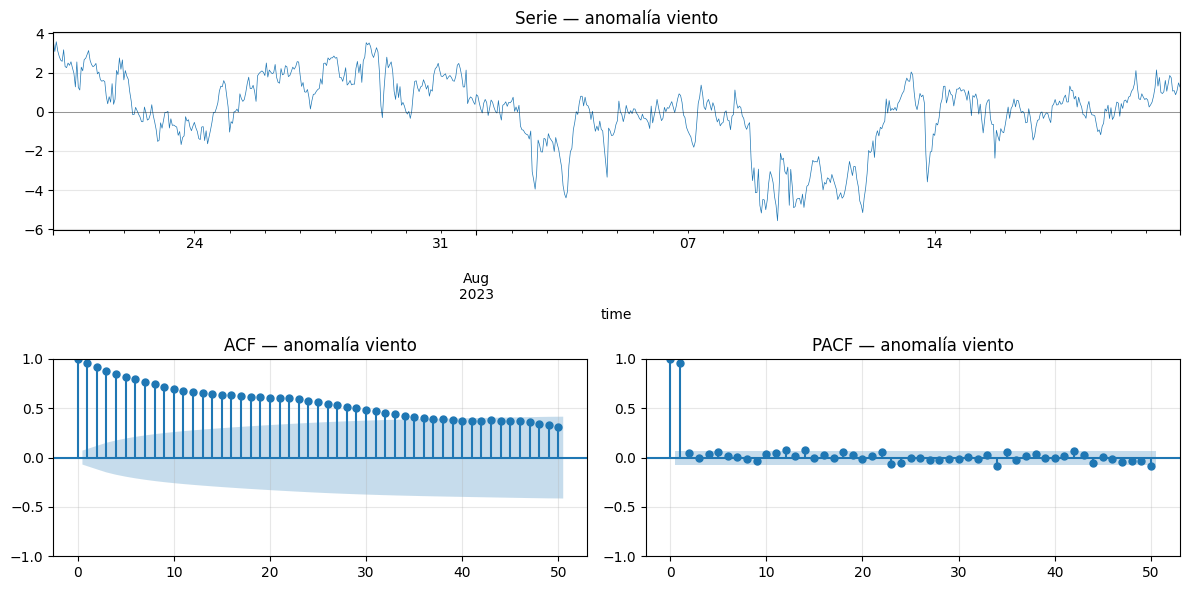

In [9]:
mirar(ws_anom, "anomalía viento", lags=50)

## P4 · Iteración Box-Jenkins · 15 min

Tres ajustes con la misma rutina: **estimar → diagnosticar → decidir**.

### Iteración 1 · AR(1)

phi = 0.960    AIC = 1169.0


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


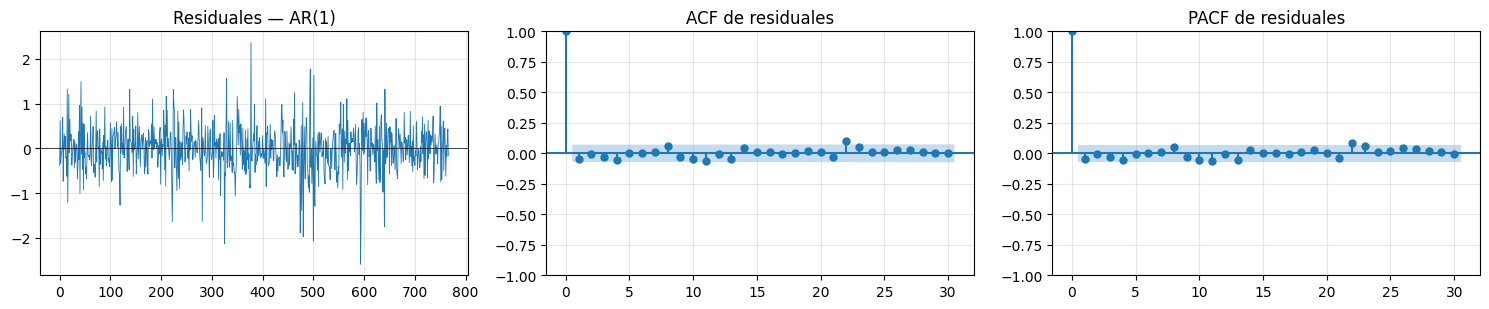

Ljung-Box · AR(1)
    lb_stat  lb_pvalue
10   9.7488     0.4628
20  16.7075     0.6719


,lb_stat,lb_pvalue
10,9.748824,0.462799
20,16.707531,0.671875


In [24]:
ar1_w = ARIMA(ws_anom, order=(1, 0, 0)).fit()
print(f"phi = {ar1_w.params['ar.L1']:.3f}    AIC = {ar1_w.aic:.1f}")
diagnostico(ar1_w, "AR(1)", lags=30)

### Iteración 2 · AR(2)

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1510      0.445      0.339      0.735      -0.722       1.024
ar.L1          0.9203      0.026     35.844      0.000       0.870       0.971
ar.L2          0.0413      0.026      1.617      0.106      -0.009       0.091
sigma2         0.2648      0.009     29.385      0.000       0.247       0.283

AIC = 1169.7  (AR(1) tenía 1169.0)


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


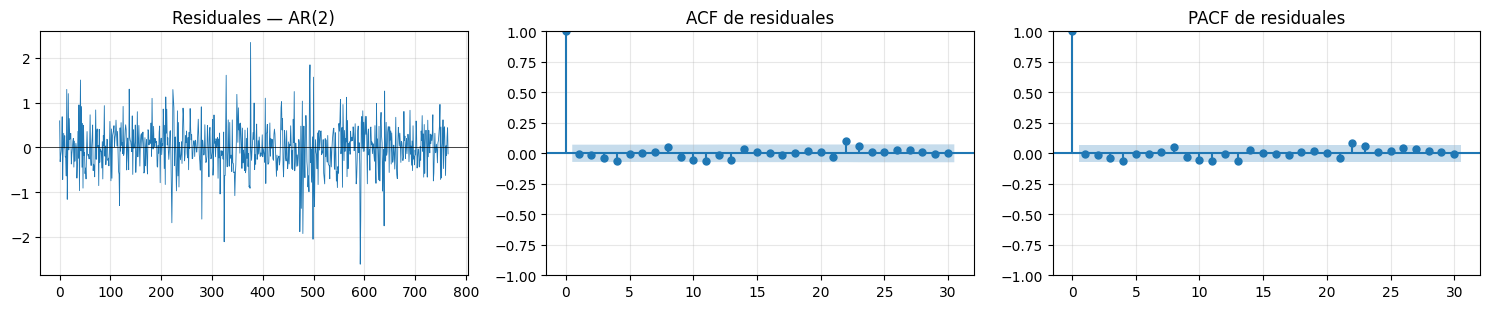

Ljung-Box · AR(2)
    lb_stat  lb_pvalue
10   9.5241     0.4832
20  16.7781     0.6673


,lb_stat,lb_pvalue
10,9.524063,0.483192
20,16.778138,0.667330


In [25]:
ar2_w = ARIMA(ws_anom, order=(2, 0, 0)).fit()
print(ar2_w.summary().tables[1])
print(f"\nAIC = {ar2_w.aic:.1f}  (AR(1) tenía {ar1_w.aic:.1f})")
diagnostico(ar2_w, "AR(2)", lags=30)

### Iteración 3 · ARMA(2, 1)

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3155      0.621      0.508      0.611      -0.901       1.532
ar.L1          1.8285      0.068     26.764      0.000       1.695       1.962
ar.L2         -0.8307      0.066    -12.494      0.000      -0.961      -0.700
ma.L1         -0.9121      0.059    -15.538      0.000      -1.027      -0.797
sigma2         0.2631      0.009     29.391      0.000       0.246       0.281

AIC = 1166.7


/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


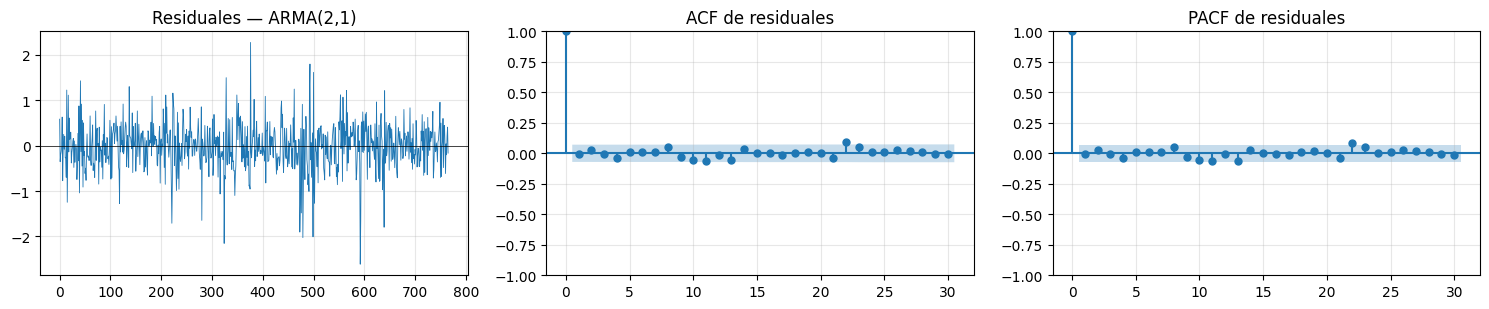

Ljung-Box · ARMA(2,1)
    lb_stat  lb_pvalue
10   7.3585     0.6912
20  14.6396     0.7966


,lb_stat,lb_pvalue
10,7.358452,0.691227
20,14.639578,0.796646


In [26]:
arma21_w = ARIMA(ws_anom, order=(2, 0, 1)).fit()
print(arma21_w.summary().tables[1])
print(f"\nAIC = {arma21_w.aic:.1f}")
diagnostico(arma21_w, "ARMA(2,1)", lags=30)

### Resumen comparativo

In [27]:
def lb_pvalue(modelo, lag=20):
    p, d, q = modelo.model.order
    resid = modelo.resid.iloc[max(p, q):]
    return acorr_ljungbox(resid, lags=[lag], return_df=True)["lb_pvalue"].iloc[0]

resumen = pd.DataFrame({
    "AIC":             [ar1_w.aic, ar2_w.aic, arma21_w.aic],
    "BIC":             [ar1_w.bic, ar2_w.bic, arma21_w.bic],
    "LB p-value (20)": [lb_pvalue(ar1_w), lb_pvalue(ar2_w), lb_pvalue(arma21_w)],
}, index=["AR(1)", "AR(2)", "ARMA(2,1)"]).round(4)
print(resumen)

                 AIC        BIC  LB p-value (20)
AR(1)      1168.9671  1182.8985           0.6719
AR(2)      1169.6618  1188.2370           0.6673
ARMA(2,1)  1166.7357  1189.9547           0.7966


## P5 · Pronóstico, frontera y puente a SARIMA · 10 min

### Pronóstico a 24 h — validación walk-forward

En lugar de pronosticar al vacío (hacia el futuro sin verdad de terreno), hacemos
algo más útil: **dejamos afuera las últimas 24 horas de la serie**, reajustamos
ARMA(2,1) solo con el resto, y comparamos el pronóstico contra los valores reales
que **sí existen** en el dataset.

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


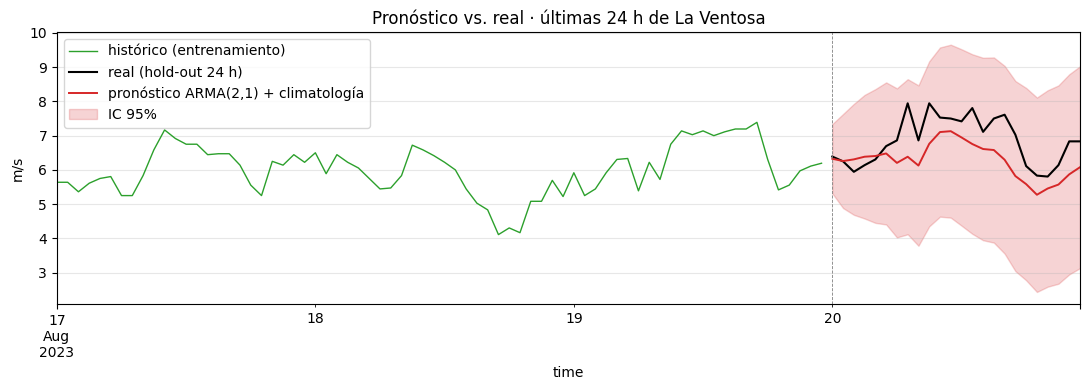

MAE          ARMA(2,1)   = 0.63 m/s
RMSE         ARMA(2,1)   = 0.75 m/s
Cobertura IC 95%         = 100%   (esperado ~95%)
MAE          persistencia = 0.56 m/s  (baseline ingenuo)


In [29]:
H = 24  # horas de hold-out

# Train/test split: el test son las últimas H horas (no las ve el modelo)
ws_anom_train = ws_anom.iloc[:-H]
viento_test   = viento.iloc[-H:]

# Reajustamos ARMA(2,1) SOLO con datos de entrenamiento
arma21_eval = ARIMA(ws_anom_train, order=(2, 0, 1)).fit()

fc = arma21_eval.get_forecast(steps=H)
fc_anom = fc.predicted_mean
ic_anom = fc.conf_int(alpha=0.05)

# Reincorporar climatología (suma sobre la anomalía pronosticada)
horas_fc = viento_test.index.hour
clima_fc = horas_fc.map(clima_h).values

fc_real = pd.Series(fc_anom.values         + clima_fc, index=viento_test.index)
ic_lo   = pd.Series(ic_anom.iloc[:, 0].values + clima_fc, index=viento_test.index)
ic_hi   = pd.Series(ic_anom.iloc[:, 1].values + clima_fc, index=viento_test.index)

# Plot: 72 h previas (train) + 24 h reales (test) + 24 h pronóstico
ventana_train = viento.iloc[-72-H:-H]

fig, ax = plt.subplots(figsize=(11, 4))
ventana_train.plot(ax=ax, lw=1.0, color="C2", label="histórico (entrenamiento)")
viento_test.plot(ax=ax, color="k",  lw=1.5, label="real (hold-out 24 h)")
fc_real.plot(ax=ax,      color="C3", lw=1.4, label="pronóstico ARMA(2,1) + climatología")
ax.fill_between(fc_real.index, ic_lo.values, ic_hi.values,
                color="C3", alpha=0.2, label="IC 95%")
ax.axvline(viento_test.index[0], color="gray", lw=0.6, ls="--")
ax.set_title("Pronóstico vs. real · últimas 24 h de La Ventosa")
ax.set_ylabel("m/s"); ax.legend(); plt.tight_layout(); plt.show()

# Métricas sobre el hold-out
real = viento_test.values
mae  = np.abs(real - fc_real.values).mean()
rmse = np.sqrt(((real - fc_real.values) ** 2).mean())
cob  = ((real >= ic_lo.values) & (real <= ic_hi.values)).mean()

# Baseline ingenuo: "mañana = hoy hora por hora" (persistencia 24h)
fc_persist = viento.iloc[-2*H:-H].values
mae_persist = np.abs(real - fc_persist).mean()

print(f"MAE          ARMA(2,1)   = {mae:.2f} m/s")
print(f"RMSE         ARMA(2,1)   = {rmse:.2f} m/s")
print(f"Cobertura IC 95%         = {cob*100:.0f}%   (esperado ~95%)")
print(f"MAE          persistencia = {mae_persist:.2f} m/s  (baseline ingenuo)")

### La frontera · ¿qué pasa si NO desestacionalizamos?

Provocación: ajustemos AR(2) directamente sobre el viento crudo (con ciclo diario).

**Mira la ACF y PACF residuales con cuidado.** Aparecen **picos claros en lags 24,
48, 72** ($\rho \approx 0.19, 0.16, 0.15$ frente a una banda de $\pm 0.04$) — el
ciclo diario que ARMA no puede capturar y que se filtró íntegro a los residuales.
Subir orden no lo arregla: ARMA no tiene mecanismo *explícito* para estacionalidad.

### ¿Y qué tan mal pronostica? Walk-forward del AR(2) crudo

Los picos residuales delatan el problema estadísticamente, pero **el costo operativo
se ve mejor en backtest**: reajustamos el AR(2) crudo dejando afuera las últimas
24 h y comparamos contra el real — igual que hicimos con ARMA(2,1) + climatología.

/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/gbv/anomalias-2026-2/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


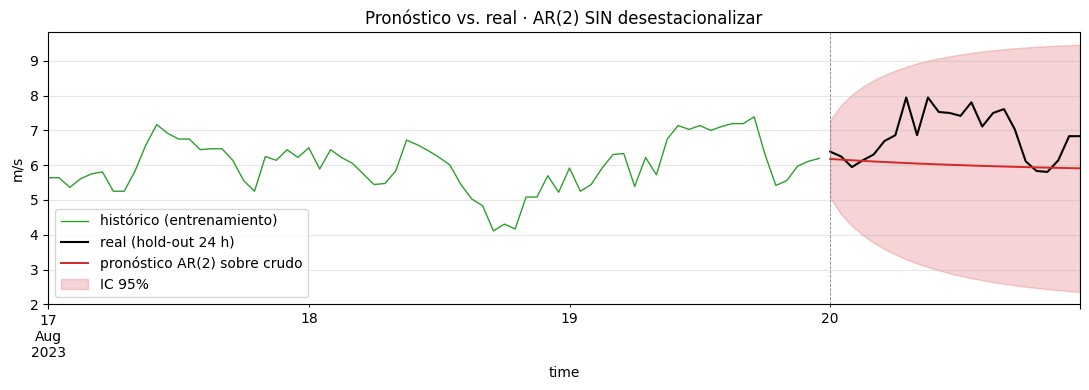

MAE  AR(2) sobre crudo   = 0.87 m/s   (vs ARMA(2,1)+clima = 0.63)
RMSE AR(2) sobre crudo   = 1.08 m/s   (vs ARMA(2,1)+clima = 0.75)
Cobertura IC 95%         = 100%


In [16]:
viento_train = viento.iloc[:-H]
ar2_crudo_eval = ARIMA(viento_train, order=(2, 0, 0)).fit()
fc_c = ar2_crudo_eval.get_forecast(steps=H)

fc_c_mean = pd.Series(fc_c.predicted_mean.values,                   index=viento_test.index)
ic_c_lo   = pd.Series(fc_c.conf_int(alpha=0.05).iloc[:, 0].values,  index=viento_test.index)
ic_c_hi   = pd.Series(fc_c.conf_int(alpha=0.05).iloc[:, 1].values,  index=viento_test.index)

fig, ax = plt.subplots(figsize=(11, 4))
ventana_train.plot(ax=ax, lw=1.0, color="C2", label="histórico (entrenamiento)")
viento_test.plot(ax=ax,  color="k",  lw=1.5, label="real (hold-out 24 h)")
fc_c_mean.plot(ax=ax,    color="C3", lw=1.4, label="pronóstico AR(2) sobre crudo")
ax.fill_between(fc_c_mean.index, ic_c_lo.values, ic_c_hi.values,
                color="C3", alpha=0.2, label="IC 95%")
ax.axvline(viento_test.index[0], color="gray", lw=0.6, ls="--")
ax.set_title("Pronóstico vs. real · AR(2) SIN desestacionalizar")
ax.set_ylabel("m/s"); ax.legend(); plt.tight_layout(); plt.show()

mae_crudo  = np.abs(real - fc_c_mean.values).mean()
rmse_crudo = np.sqrt(((real - fc_c_mean.values) ** 2).mean())
cob_crudo  = ((real >= ic_c_lo.values) & (real <= ic_c_hi.values)).mean()
print(f"MAE  AR(2) sobre crudo   = {mae_crudo:.2f} m/s   (vs ARMA(2,1)+clima = {mae:.2f})")
print(f"RMSE AR(2) sobre crudo   = {rmse_crudo:.2f} m/s   (vs ARMA(2,1)+clima = {rmse:.2f})")
print(f"Cobertura IC 95%         = {cob_crudo*100:.0f}%")

## Apéndice · descarga del CSV

```bash
curl "https://archive-api.open-meteo.com/v1/archive?\
latitude=16.55&longitude=-94.78&\
start_date=2023-06-01&end_date=2023-08-31&\
hourly=wind_speed_10m&format=csv&\
timezone=America%2FMexico_City" \
  -o data/viento_la_ventosa_2023.csv
```

Open-Meteo entrega reanálisis ERA5 sin autenticación. Calidad comparable a
NREL WIND Toolkit para evaluación de recurso.

Cita:
> Hersbach, H., et al. (2020). *The ERA5 global reanalysis*. QJRMS, 146, 1999–2049.